# Volleyball Tagging System: Model Evaluation

Authors: Patrick Dang, Abiola Raji

## Setup

In [23]:
from pathlib import Path

import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
)

from transformations import val_transform

In [24]:
if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"

print(f"Using device: {device}")

Using device: mps


## Load Model

In [25]:
class CNN(nn.Module):
    def __init__(self, num_classes=5):
        super().__init__()
        self.network = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Flatten(),
            nn.LazyLinear(256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.LazyLinear(num_classes)
        )

    def forward(self, X):
        return self.network(X)

In [26]:
WEIGHTS_PATH = Path("weights/action_model.pt")
DATASET_PATH = Path("../VolleyballDataset")
BATCH_SIZE = 32

# Load test set first to trigger LazyLinear shape inference
test_set = ImageFolder(DATASET_PATH / "test", val_transform)
test_loader = DataLoader(test_set, batch_size=BATCH_SIZE, shuffle=False)

CLASS_NAMES = test_set.classes
NUM_CLASSES = len(CLASS_NAMES)
print(f"Classes ({NUM_CLASSES}): {CLASS_NAMES}")
print(f"Test samples: {len(test_set)}")

Classes (5): ['block', 'defense', 'serve', 'set', 'spike']
Test samples: 1663


In [27]:
# Peek at checkpoint to get the true output dimension
checkpoint = torch.load(WEIGHTS_PATH, map_location=device)
checkpoint_classes = checkpoint["network.19.weight"].shape[0]
print(f"Checkpoint output classes: {checkpoint_classes}")
print(f"Dataset classes: {NUM_CLASSES} → {CLASS_NAMES}")

model = CNN(num_classes=checkpoint_classes).to(device)

# Forward pass one batch to initialize LazyLinear before loading weights
sample_batch, _ = next(iter(test_loader))
_ = model(sample_batch.to(device))

model.load_state_dict(checkpoint)
model.eval()
print("Model loaded successfully.")

if checkpoint_classes != NUM_CLASSES:
    print(f"\n⚠️  WARNING: Model was trained on {checkpoint_classes} classes but test set has {NUM_CLASSES}.")
    print("   Predictions will use dataset class indices — only valid if the class mapping is consistent.")
    print("   Retrain with the correct num_classes for reliable evaluation.")

Checkpoint output classes: 5
Dataset classes: 5 → ['block', 'defense', 'serve', 'set', 'spike']
Model loaded successfully.


## Run Inference on Test Set

In [28]:
all_labels = []
all_preds = []
all_probs = []
all_images = []

softmax = nn.Softmax(dim=1)

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        probs = softmax(outputs)
        _, predicted = torch.max(outputs, 1)

        all_labels.extend(labels.numpy())
        all_preds.extend(predicted.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
        all_images.extend(images.cpu())

all_labels = np.array(all_labels)
all_preds = np.array(all_preds)
all_probs = np.array(all_probs)

print(f"Inference complete on {len(all_labels)} samples.")

Inference complete on 1663 samples.


## Model Performance (Accuracy, Precision, Recall, F1-Score)

In [29]:
accuracy  = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds, average="weighted", zero_division=0)
recall    = recall_score(all_labels, all_preds, average="weighted", zero_division=0)
f1        = f1_score(all_labels, all_preds, average="weighted", zero_division=0)

print("="*45)
print(f"  Test Accuracy  : {accuracy  * 100:.2f}%")
print(f"  Precision      : {precision * 100:.2f}%")
print(f"  Recall         : {recall    * 100:.2f}%")
print(f"  F1-Score       : {f1        * 100:.2f}%")
print("="*45)

  Test Accuracy  : 93.08%
  Precision      : 93.06%
  Recall         : 93.08%
  F1-Score       : 92.96%


In [30]:
print("\nPer-Class Classification Report:\n")
print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES, zero_division=0))


Per-Class Classification Report:

              precision    recall  f1-score   support

       block       0.89      0.95      0.92       423
     defense       0.67      0.20      0.31        10
       serve       0.94      0.99      0.96       148
         set       0.94      0.93      0.93       456
       spike       0.95      0.92      0.93       626

    accuracy                           0.93      1663
   macro avg       0.88      0.80      0.81      1663
weighted avg       0.93      0.93      0.93      1663



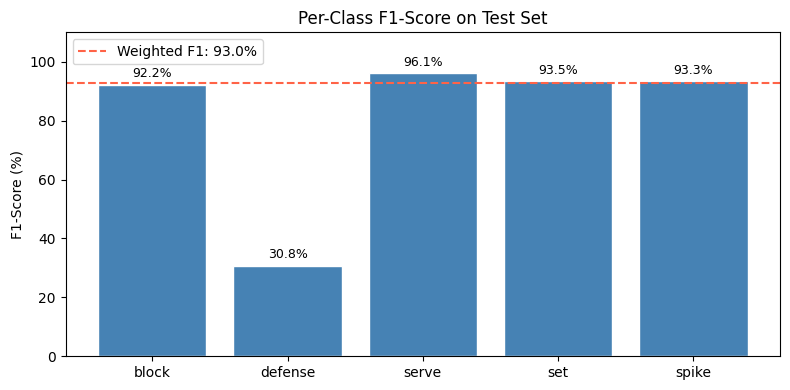

In [31]:
# Per-class F1 bar chart
per_class_f1 = f1_score(all_labels, all_preds, average=None, zero_division=0)

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(CLASS_NAMES, per_class_f1 * 100, color="steelblue", edgecolor="white")
ax.set_ylim(0, 110)
ax.set_ylabel("F1-Score (%)")
ax.set_title("Per-Class F1-Score on Test Set")
ax.axhline(f1 * 100, color="tomato", linestyle="--", label=f"Weighted F1: {f1*100:.1f}%")
ax.legend()

for bar, val in zip(bars, per_class_f1):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1.5,
            f"{val*100:.1f}%", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

## Confusion Matrix

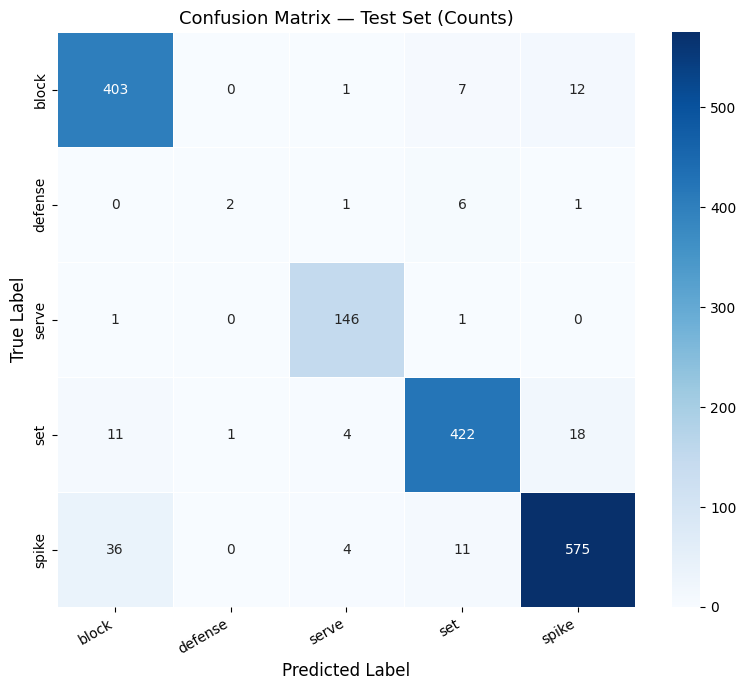

In [32]:
cm = confusion_matrix(all_labels, all_preds)

fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
    linewidths=0.5, ax=ax
)
ax.set_xlabel("Predicted Label", fontsize=12)
ax.set_ylabel("True Label", fontsize=12)
ax.set_title("Confusion Matrix — Test Set (Counts)", fontsize=13)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

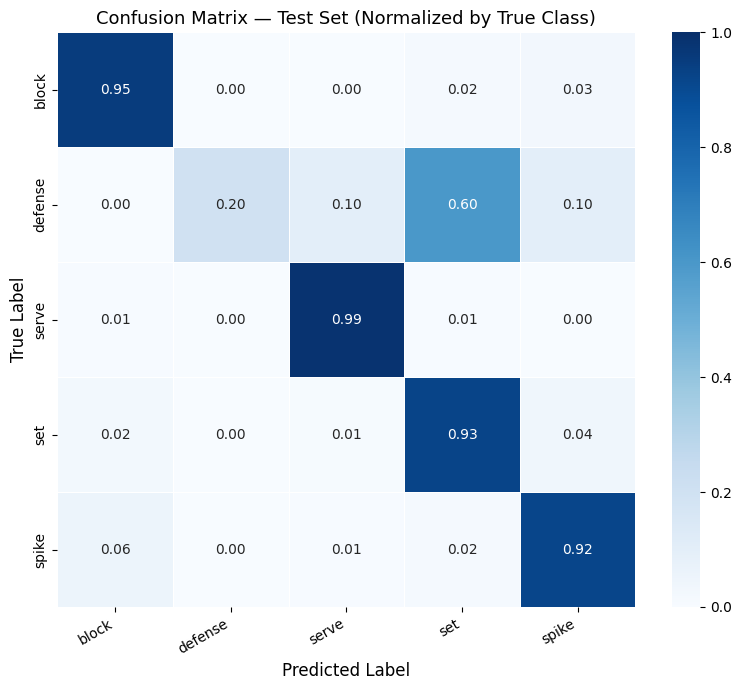

In [33]:
# Normalized confusion matrix (row = recall per class)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(
    cm_norm, annot=True, fmt=".2f", cmap="Blues",
    xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
    linewidths=0.5, vmin=0, vmax=1, ax=ax
)
ax.set_xlabel("Predicted Label", fontsize=12)
ax.set_ylabel("True Label", fontsize=12)
ax.set_title("Confusion Matrix — Test Set (Normalized by True Class)", fontsize=13)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

## Sample Classification Results with Confidence Scores

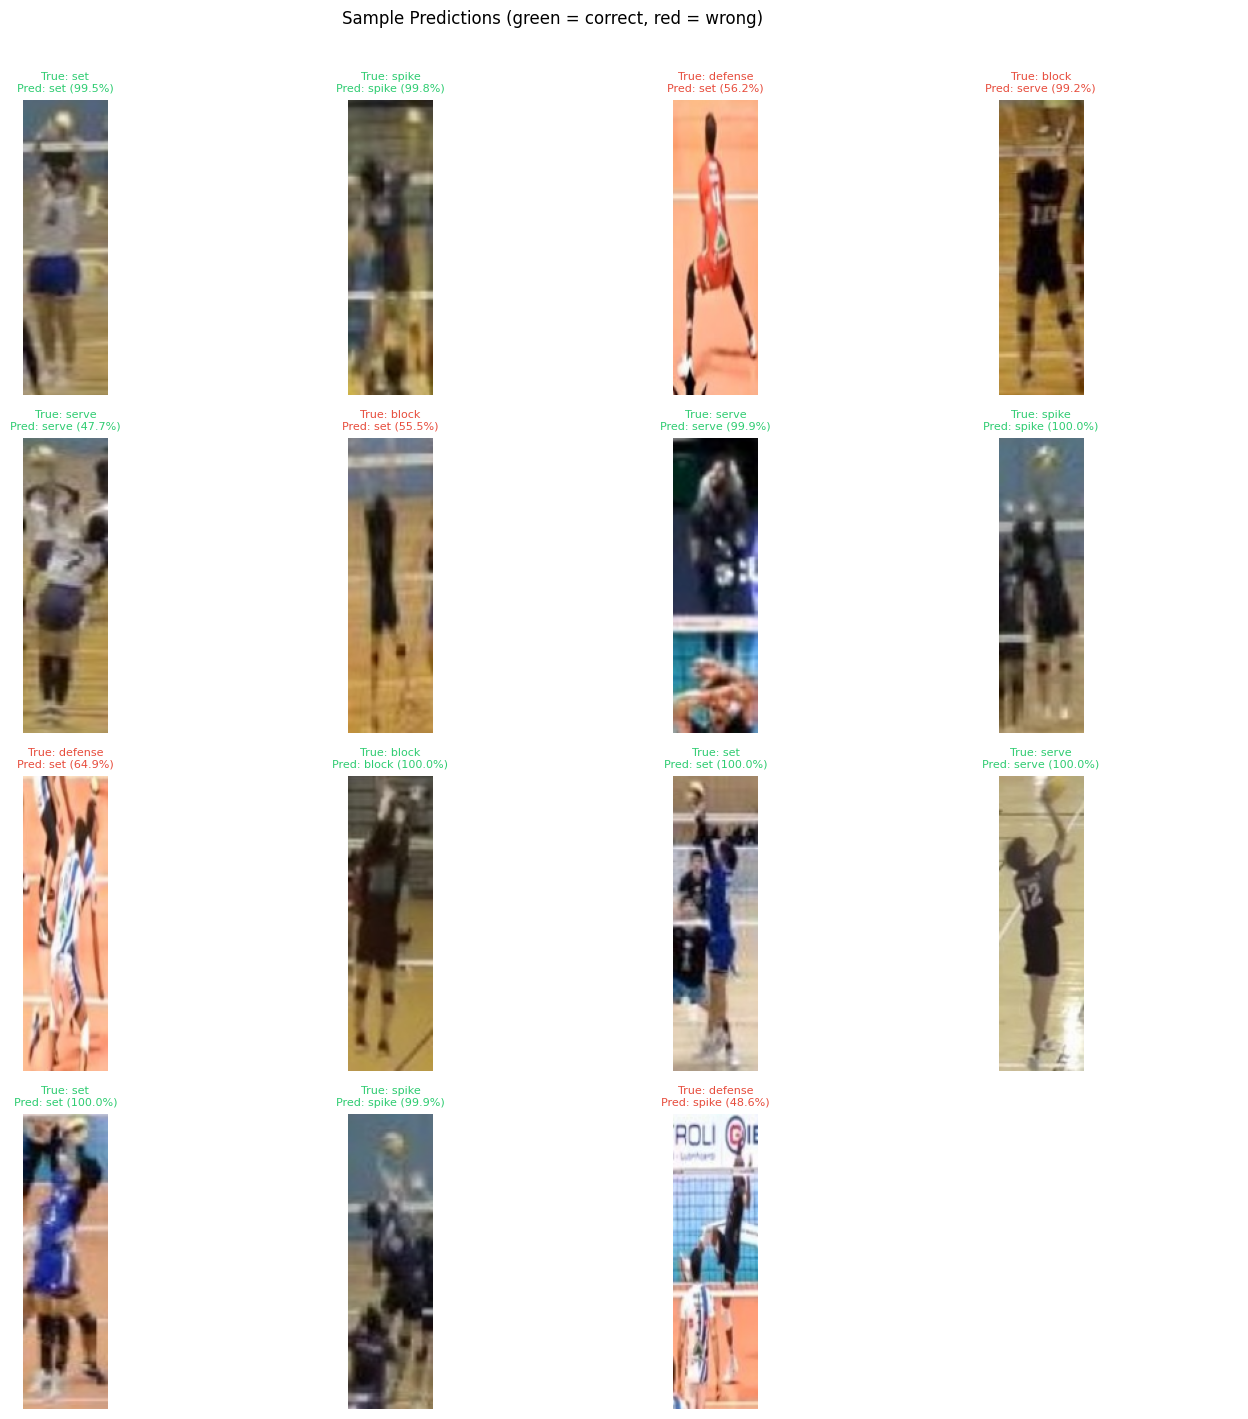

In [34]:
def denormalize(tensor):
    """Undo ImageNet normalization for display."""
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    return (tensor * std + mean).clamp(0, 1).permute(1, 2, 0).numpy()


def show_sample_predictions(images, labels, preds, probs, class_names, n=16, cols=4):
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 3.5, rows * 3.5))
    axes = axes.flatten()

    # Sample evenly across classes
    indices = []
    for c in range(len(class_names)):
        class_idx = np.where(labels == c)[0]
        n_sample = max(1, n // len(class_names))
        sampled = np.random.choice(class_idx, size=min(n_sample, len(class_idx)), replace=False)
        indices.extend(sampled.tolist())
    indices = indices[:n]
    np.random.shuffle(indices)

    for ax, idx in zip(axes, indices):
        img = denormalize(images[idx])
        true_label = class_names[labels[idx]]
        pred_label = class_names[preds[idx]]
        confidence = probs[idx][preds[idx]] * 100
        correct = labels[idx] == preds[idx]

        ax.imshow(img)
        ax.axis("off")
        color = "#2ecc71" if correct else "#e74c3c"
        title = f"True: {true_label}\nPred: {pred_label} ({confidence:.1f}%)"
        ax.set_title(title, fontsize=8, color=color)
        for spine in ax.spines.values():
            spine.set_edgecolor(color)
            spine.set_linewidth(3)

    for ax in axes[len(indices):]:
        ax.axis("off")

    plt.suptitle("Sample Predictions (green = correct, red = wrong)", fontsize=12, y=1.01)
    plt.tight_layout()
    plt.show()


np.random.seed(42)
show_sample_predictions(all_images, all_labels, all_preds, all_probs, CLASS_NAMES, n=16)

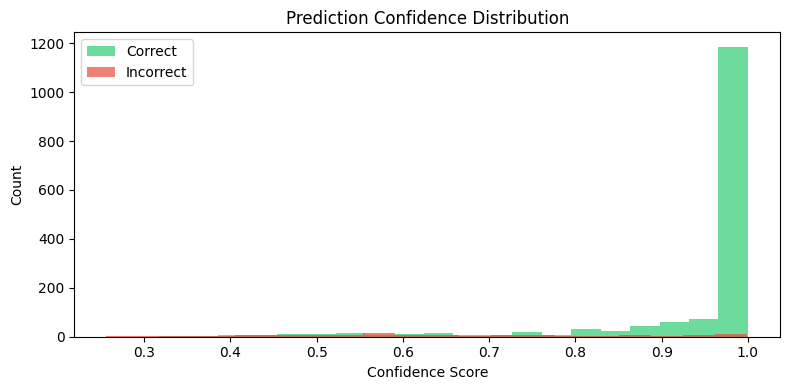

In [35]:
# Confidence distribution: correct vs incorrect
correct_mask = all_labels == all_preds
conf_correct   = all_probs[correct_mask,  all_preds[correct_mask]]
conf_incorrect = all_probs[~correct_mask, all_preds[~correct_mask]]

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(conf_correct,   bins=20, alpha=0.7, label="Correct",   color="#2ecc71")
ax.hist(conf_incorrect, bins=20, alpha=0.7, label="Incorrect", color="#e74c3c")
ax.set_xlabel("Confidence Score")
ax.set_ylabel("Count")
ax.set_title("Prediction Confidence Distribution")
ax.legend()
plt.tight_layout()
plt.show()

## Misclassified Examples

In [36]:
wrong_idx = np.where(all_labels != all_preds)[0]
print(f"Total misclassified: {len(wrong_idx)} / {len(all_labels)} "
      f"({len(wrong_idx)/len(all_labels)*100:.1f}%)")

Total misclassified: 115 / 1663 (6.9%)


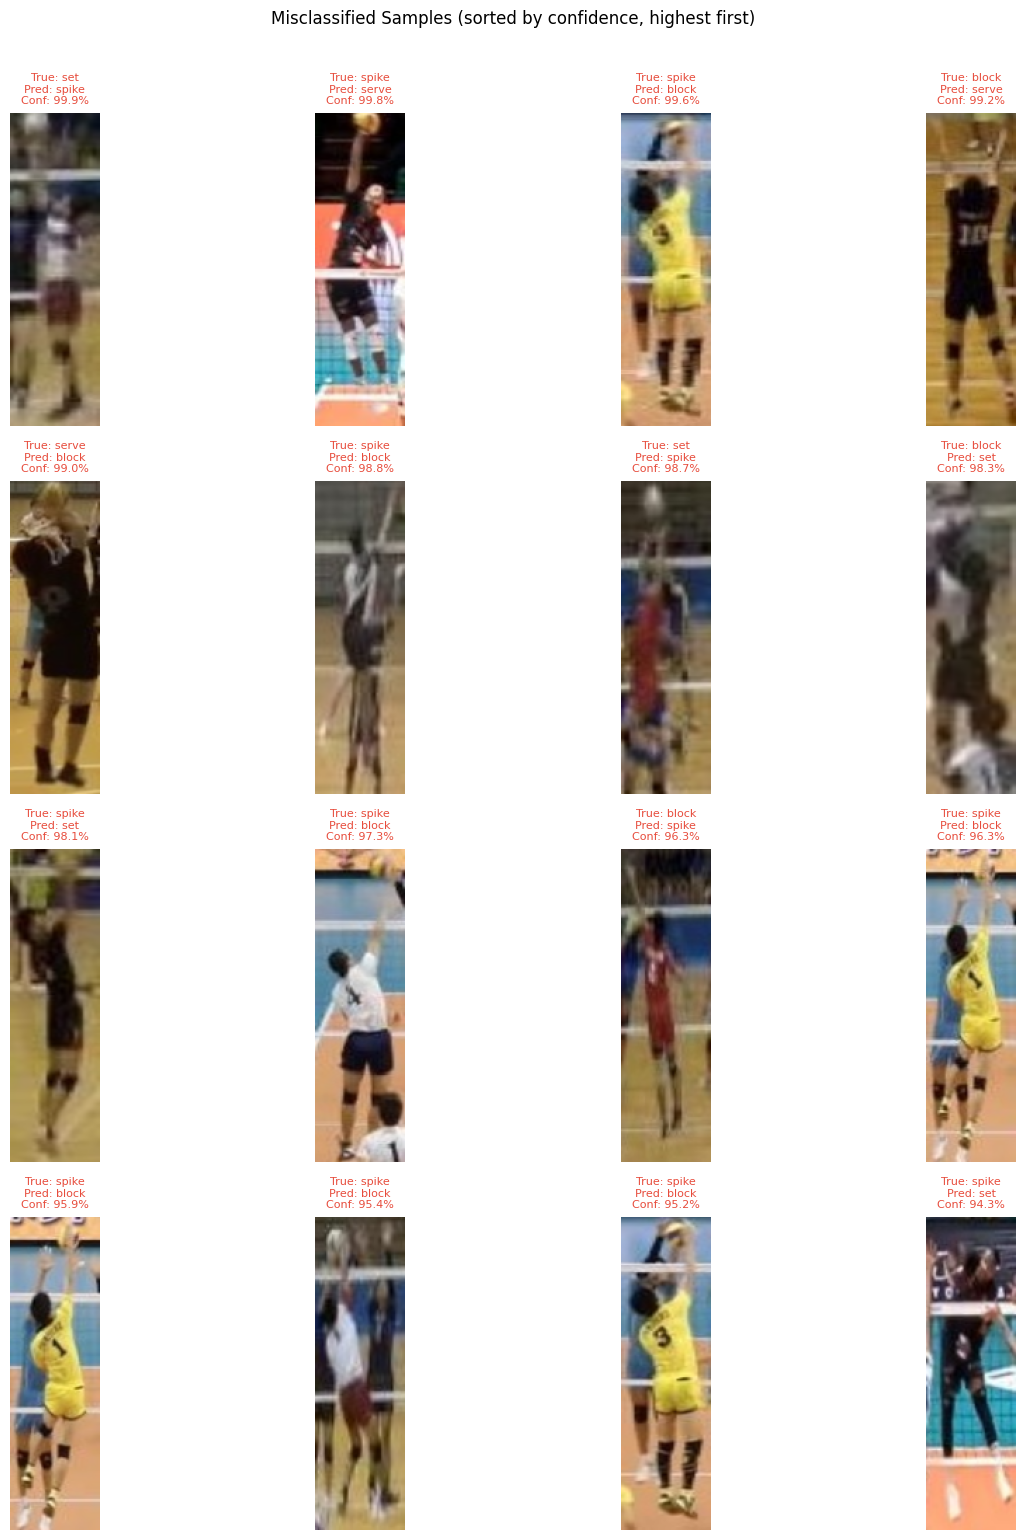

In [37]:
# Show up to 16 misclassified examples, sorted by confidence (most confidently wrong first)
wrong_confs = all_probs[wrong_idx, all_preds[wrong_idx]]
sorted_wrong = wrong_idx[np.argsort(-wrong_confs)]  # descending
display_idx = sorted_wrong[:16]

cols = 4
rows = (len(display_idx) + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(cols * 3.5, rows * 3.8))
axes = axes.flatten()

for ax, idx in zip(axes, display_idx):
    img = denormalize(all_images[idx])
    true_label = CLASS_NAMES[all_labels[idx]]
    pred_label = CLASS_NAMES[all_preds[idx]]
    confidence = all_probs[idx][all_preds[idx]] * 100

    ax.imshow(img)
    ax.axis("off")
    ax.set_title(
        f"True: {true_label}\nPred: {pred_label}\nConf: {confidence:.1f}%",
        fontsize=8, color="#e74c3c"
    )

for ax in axes[len(display_idx):]:
    ax.axis("off")

plt.suptitle("Misclassified Samples (sorted by confidence, highest first)", fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

In [38]:
# Confusion pairs: which classes get confused most
from collections import Counter

confusion_pairs = Counter(
    (CLASS_NAMES[t], CLASS_NAMES[p])
    for t, p in zip(all_labels[wrong_idx], all_preds[wrong_idx])
)

print("Top misclassification pairs (True → Predicted):")
for (true_c, pred_c), count in confusion_pairs.most_common(10):
    print(f"  {true_c:>15} → {pred_c:<15}  ({count} samples)")

Top misclassification pairs (True → Predicted):
            spike → block            (36 samples)
              set → spike            (18 samples)
            block → spike            (12 samples)
              set → block            (11 samples)
            spike → set              (11 samples)
            block → set              (7 samples)
          defense → set              (6 samples)
              set → serve            (4 samples)
            spike → serve            (4 samples)
            block → serve            (1 samples)
